# Exercício: Análise de fraude em transação de cartão de crédito

O objetivo desse exercício é utilizar conhecimentos de análise de dados conjuntamente com modelos simples de aprendizagem estatística em um conjunto de dados para treinar um modelo que detecta fraudes em transações de cartão de crédito

### Importação inicial de pacotes
Primeiro, importamos alguns pacotes iniciais. Durante o arquivo e conforme a necessidade, importamos outros

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


### Coleta de dados
Os dados são coletados via API por um URL. Após coletar os dados, em formato csv, colocamo-os em um dataframe de pandas e exibimos os primeiro elementos com .head()

In [2]:
url="https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df=pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


A coluna Class corresponde à 0: não houve fraude e 1: houve fraude. Utilizando .value_counts podemos contar quantos elementos de cada grupo estão presents no dataframe. Atenção no normalize=True, que torna os valores em porcentagens e não contagens absolutas.

In [3]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Para uma análise mais robusta, transformamos os dados de valores absolutos para valores log. Isso deve-se ao fato de que uma transação de cem mil em um universo de transações de média cem pode causar um desequilíbrio. Transformar em log homogeiniza os dados

In [4]:
df["Amount_log"]=np.log1p(df["Amount"])

A função StandardScaler transforma os dados em uma nova distribuição subtraindo a média dos dados e dividindo pela variância. Assim, a distribuição obtida tem média zero e variância unitária.

In [5]:
scaler=StandardScaler()
df["Amount_scaled"]=scaler.fit_transform(df[["Amount"]])

Para treinar um determinado modelo, é uma boa prática dividir o dataset em parte de treinamento e parte de teste. O treinamento serve para treinar o modelo enquanto que o de teste é um conjunto diferente do conjunto de treino e serve para verificar como o modelo obtido se comporta quando comparado com dados não utilizados no treino.

A presença de stratify=y nos diz que haverá uma mesma proporção de dados "y" (ou seja, contagem de fraudes) tanto nos dados de treino quanto de teste. Isso é necessário, visto que sem isso haveria chance (em um caso extremo) de todos os dados de fraude bancária irem para o conjunto de teste, e assim o modelo seria incapaz de detectar qualquer tipo de fraude de maneira correta. Com esse comando, garantimos que haverá fraudes tanto no conjunto de testes quanto de treino.

In [6]:
x=df.drop("Class", axis=1)
y=df["Class"]

x_train, x_test, y_train, y_test=train_test_split(
    x, y, stratify=y, test_size=0.3, random_state=42
)

### Exploração inicial dos dados

É possível realizar algumas explorações iniciais adicionais dos dados. Abaixo iniciamos por mostrar um gráfico boxplot que mostra a quantidade "Amount" (em escala log) em operações que são ou não fraudulentas. Nesse caso, podemos notar que operações fraudulentas tendem à não ter valores muito altos

<Axes: xlabel='Class', ylabel='Amount_scaled'>

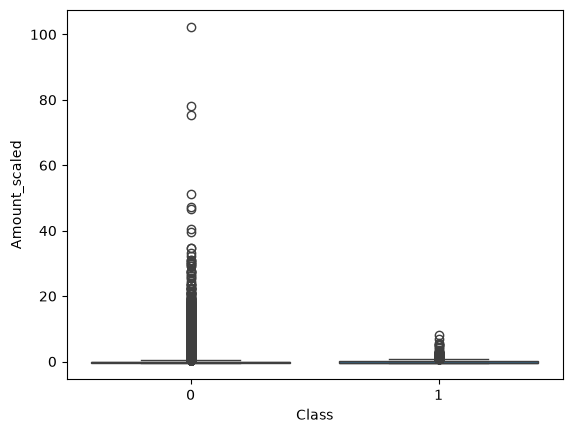

In [29]:
import seaborn as sns

sns.boxplot(
    data=df,
    x="Class",
    y="Amount_scaled"
)


Abaixo iremos incluir o mesmo gráfico de cima, mas eliminando os outliers. Note que o percentil de 75% é superior no caso de fraudes e o percentil 100% (e que não inclui outliers nesse caso) é também superior. De toda forma, o percentil 50% é inferior. Isso indica que em geral fraudes de crédito tendem à apresentar valores superiores, mas que até 50% dessas fraudes representam valores baixos. 

<Axes: xlabel='Class', ylabel='Amount'>

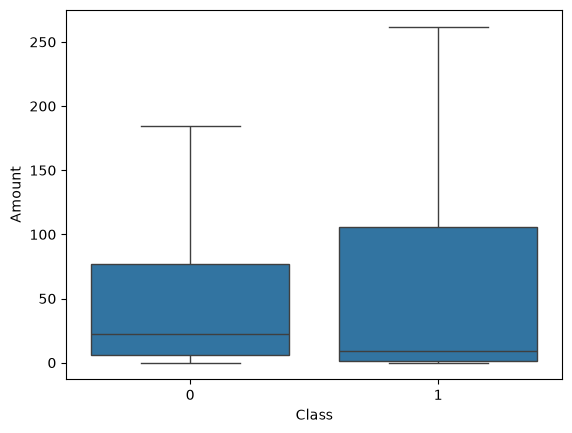

In [27]:
sns.boxplot(
    data=df,
    x="Class",
    y="Amount",
    showfliers=False
)

### Regressão Logística

Iniciamos importando o modelo de regressão logística. O modelo de regressão logística é utilizado quando buscamos responder perguntas de classificação. Nesse caso, queremos obter se um determinado dado é ou não uma fraude bancária. 

No modelo matemático, a regressão é feita de maneira semelhante à regressão linear, mas usando a função logística (que tem um formato semelhante à um S). Por se tratar de uma curva contínua, o modelo escolhe a classificação baseado em o quão próximo o ponto está da resposta qualitativa (normalmente isso é feito introduzindo uma numeração de 0 e 1 para perguntas qualitativas de dois níveis, como nesse caso; como fraude=1 e não fraude=0, podemos decidir que um ponto 0.8, por exemplo, será classificado como fraude, visto que está mais próximo de 1).

Para o modelo abaixo realizamos 1000 iterações, que não gera uma convergência completa, como apontado pelo ConvergenceWarning

In [7]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)
y_pred=model.predict(x_test)

d:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Para averiguar a qualidade de um fit, utilizamos o classification report. Nesse, há algumas métricas importantes. 

Precisão: TP/TP+FP - é a proporção de positivos (nesse caso, leia-se fraude) verdadeiros que o modelo acertou em comparação com todos os positivos obtidos (incluindo aqueles em que o modelo errou).

Recall: TP/TP+FN - é a proporção de positivos verdadeiros que o modelo acertou em comparação com todos aqueles que ele deveria classificar como positivos (mas que podem ter sido classificados falsamente como negativos).

F1-score: Média harmônica entre a precisão e o recall.

Note que para um programa que quer detectar fraudes em transações de cartão de crédito, queremos aumentar o Recall o máximo possível, visto que queremos que FN seja próximo de zero (e nesse caso o recall é próximo de 1)

In [8]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.64      0.73       148

    accuracy                           1.00     85443
   macro avg       0.93      0.82      0.87     85443
weighted avg       1.00      1.00      1.00     85443



Para obter características sobre o modelo e sua qualidade em representar os dados, abaixo incluímos duas curvas de extrema importância. Iniciamos pela importação dos pacotes em que elas são apresentadas.

A curva ROC (Receiver Operating Characteristic) é uma curva que descreve a qualidade do modelo colocando no eixo X a taxa de falsos positivos (ou seja, as operações que nosso modelo detecta como fraude quando não se trata de fraude) e o eixo Y a taxa de positivos verdadeiros. Quanto mais próximo do canto superior esquerdo está a curva, melhor é nosso modelo visto que isso quer dizer que há menos falsos positivos e mais positivos verdadeiros. Também é incluído a quantidade conhecida como AUC, ou Area Under Curve, um parâmetro no intervalo [0,1] em que quanto mais próximo de um, maior a área debaixo da curva (e portanto mais próximo do canto superior esquerdo está a curva).

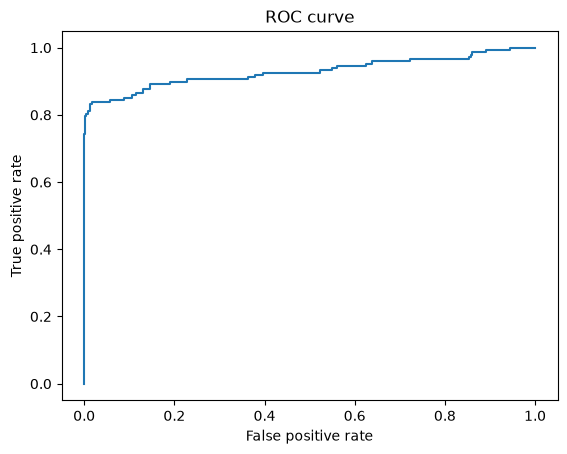

AUC: 0.9283981824605543


In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs=model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve (y_test, y_probs)

plt.plot(fpr,tpr)
plt.title("ROC curve")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

Outra forma de avaliar a qualidade de nosso modelo de aprendizagem estatística é a partir da chamada Precision-Recall curve. Como explicado anteriormente, a precisão está relacionada com a quantidade de positivos que o modelo acertou em relação ao total de positivos. Já o recall representa a quantidade de positivos que o modelo acertou dentre todos que ele deveria classificar como positivos. Como já discutido, queremos maximizar o recall sem perder a precisão completamente no processo.

Nesse contexto, a curva abaixo ajuda-nos a decidir exatamente em que região do gráfico queremos estar: quanto mais próximo do canto superior direito, melhor. Em especial, como desejamos priorizar o recall, também é possível abrir mão de parte da precisão desde que isso aumente o recall. 

Normalmente a região do gráfico em que estaremos é decidida definindo um valor de corte mínimo (mais disso adiante).

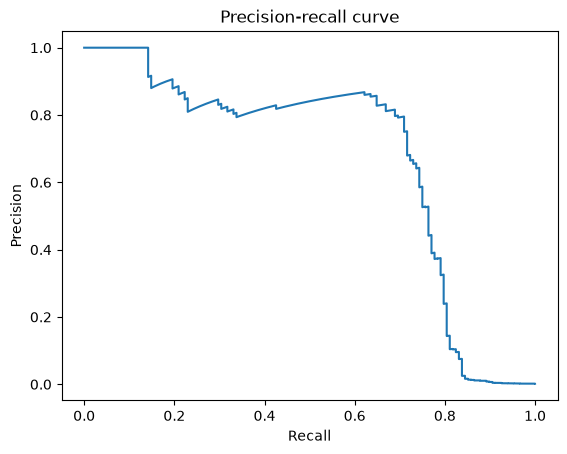

In [10]:
from sklearn.metrics import precision_recall_curve


precision, recall, _ = precision_recall_curve (y_test, y_probs)

plt.plot(recall,precision)
plt.title("Precision-recall curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

#### Balanceamento de dados

O undersampling é uma maneira de balancear os dados tomando a classe que possui mais dados e diminuindo a sua quantidade até que esta esteja com a mesma quantidade que a classe com menos dados. Note que com isso estamos reduzindo a quantidade de dados disponíveis para não fraude, o que pode comprometer a qualidade do modelo.

In [11]:
#Undersampling
fraudes = df[df["Class"]==1]
normais = df[df["Class"]==0].sample(len(fraudes),random_state=42)

df_under = pd.concat([fraudes,normais])

Por outro lado, o oversampling cria novos dados da classe minoritária baseando-se nos dados disponíveis. É importante ressaltar que isso pode trazer problemas, visto que estamos criando novos dados artificialmente para nosso dataset.

In [12]:
#Oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE()
x_res, y_res = smote.fit_resample (x,y)

### Classificador Random Forest

O classificador random forest é um tipo de classificador da família de árvores de decisão. O random forest emprega algumas características como a construção de árvores a partir de uma randomização dos preditores possíveis em cada nó além de utilizar bootstrap em sua construção.

Abaixo iniciamos pela importação do pacote, e depois realizamos um fit, calculamos uma predição e um classification report. É importante notar que nesse modelo obtivemos um recall de 0.8, superior à antes, mas a precisão decaiu, resultando em um f1-score de 0.77, levemente superior aos 0.73 obtidos para a classificação pela regressão logística.

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.74      0.80      0.77       148

    accuracy                           1.00     85443
   macro avg       0.87      0.90      0.89     85443
weighted avg       1.00      1.00      1.00     85443



Abaixo incluímos uma aplicação da função Pipeline que tem como objetivo realizar a regressão e a padronização dos dados de uma única vez. A vantagem é não precisar realizar cada etapa desse ajuste separadamente.

In [14]:
from sklearn.pipeline import Pipeline

pipeline=Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

Neste trecho estamos diminuindo o corte, o que faz com que mais dados sejam classificados como fraude. Por padrão, os classificadores acima utilizam 0.5 de corte, ou seja, se y>0.5 então o modelo classifica como fraude. Nesse caso, o nosso corte está em 0.3, o que significa que se nosso modelo obtiver um y>0.3 ele será classificado como fraude. Nesse tipo de situação estamos dizendo ao nosso modelo "eu aceito classificar como fraude mais dados que não são fraude, desde que isso diminua a quantidade de falsos negativos (ou seja, fraudes que não foram corretamente classificadas)"

In [15]:
threshold=0.3

y_pred_custom=(y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.81      0.68      0.74       148

    accuracy                           1.00     85443
   macro avg       0.91      0.84      0.87     85443
weighted avg       1.00      1.00      1.00     85443



### XGBoost

Além  do Random Forest, há outros modelos na família dos classificadores de árvores. Nesse caso, o classificador apresentado abaixo trata-se de um que utiliza o chamado XGBoost, um subtipo de algorítmo de Boosting. Essencialmente, esse tipo de algorítmo constrói novas árvores e olha o erro cometido pela árvore anterior com o objetivo de reduzir esse erro.

In [16]:
from xgboost import XGBClassifier

xgb=XGBClassifier(
    scale_pos_weight=10, #Ajuda com desbalanceamento
    use_label_encoder=False,
    eval_metric="logloss"
)
xgb.fit(x_train,y_train)

y_pred_xgb=xgb.predict(x_test)

d:\Python\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:31:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Abaixo incluímos também um classification report do modelo acima. Note que dentre os modelos utilizados esse é o que possui melhor valor de f1-score, por manter um bom recall e uma boa precisão.

In [17]:
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



Uma característica importante (e que acontece em geral para esse tipo de modelo) é que é possível identificar quais das variáveis possui maior impacto no problema de classificação. Abaixo, está incluso a coleta desse dado junto do plot que mostra isso. Note: existe claramente um dos dados que possui a maior de todas as importâncias, além de outras 4 que também são relevantes. As demais, apesar de numerosas, não são tão importantes no processo de decisão.

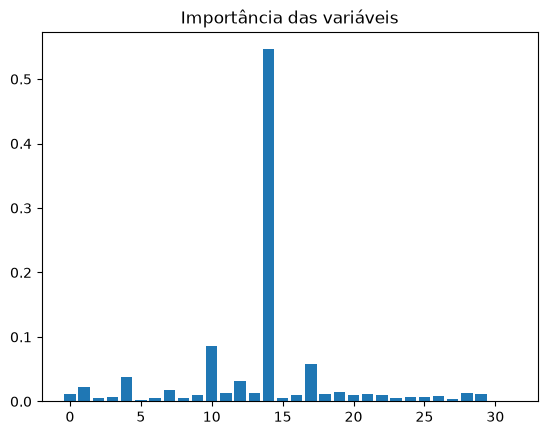

In [18]:
import matplotlib.pyplot as plt

importancias=xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()

### Mais características sobre modelos de classificação

Além dos métodos anteriores, é possível realizar uma varredura nos parâmetros do modelo, escolhendo diversas combinações (uma forma de Grid Search, ou busca em grelhas) e observando qual delas melhor se adapta aos dados. Além do fit, apresentamos também o resultado final para o melhor modelo.

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid={
    "max_depth": [3,5],
    "n_estimators":[50,100]
}

grid=GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(x_train, y_train)

print("Melhor modelo:", grid.best_params_)

Melhor modelo: {'max_depth': 5, 'n_estimators': 100}


O SHAP mostra o impacto de cada uma das variáveis na decisão do modelo. Utilizamos o pacote SHAP e sua função Explainer para exibir os dados que refletem isso.

d:\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


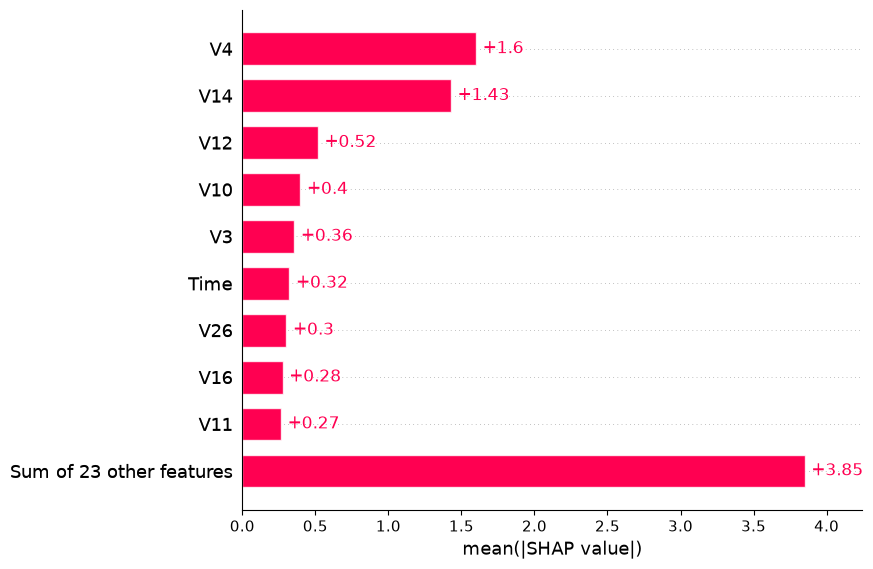

In [20]:
import shap

explainer=shap.Explainer(xgb)
shap_values=explainer(x_test[:100])

shap.plots.bar(shap_values)